# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [14]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../week05/airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [15]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


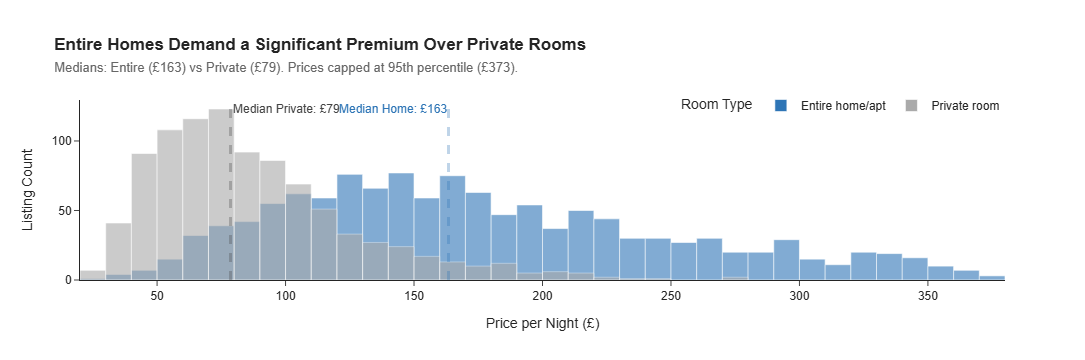

In [16]:
# Task 1
# 1. Filter data for the two room types
df_task1 = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])].copy()

# 2. Calculate medians for annotations
med_home = df_task1[df_task1['room_type'] == 'Entire home/apt']['price'].median()
med_private = df_task1[df_task1['room_type'] == 'Private room']['price'].median()

# 3. Create Histogram
fig1 = px.histogram(
    df_task1, 
    x="price", 
    color="room_type",
    barmode='overlay',
    opacity=0.6,
    nbins=40,
    color_discrete_map={'Entire home/apt': '#2E75B6', 'Private room': '#AAAAAA'},
    title="<b>Entire Homes Demand a Significant Premium Over Private Rooms</b><br><span style='font-size:13px; color:#666666'>Medians: Entire (£163) vs Private (£79). Prices capped at 95th percentile (£373).</span>",
    labels={'price': 'Price per Night (£)', 'count': 'Number of Listings'},
    template='simple_white'
)

# 4. Add vertical lines for medians 
fig1.add_vline(
    x=med_home, 
    line_dash="dash", 
    line_color="#2E75B6", 
    line_width=3, 
    layer='above',
    annotation_text=f"Median Home: £{med_home:.0f}", 
    annotation_position="top left",
    annotation_font_color="#2E75B6"
)

fig1.add_vline(
    x=med_private, 
    line_dash="dash", 
    line_color="#444444", 
    line_width=3, 
    layer='above',
    annotation_text=f"Median Private: £{med_private:.0f}", 
    annotation_position="top right", 
    annotation_font_color="#444444"
)
fig1.update_layout(
    font=dict(family="Arial"),
    legend=dict(title="Room Type", orientation='h', y=1.05, x=1, xanchor='right'),
    yaxis_title="Listing Count"
)
fig1.show()


## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

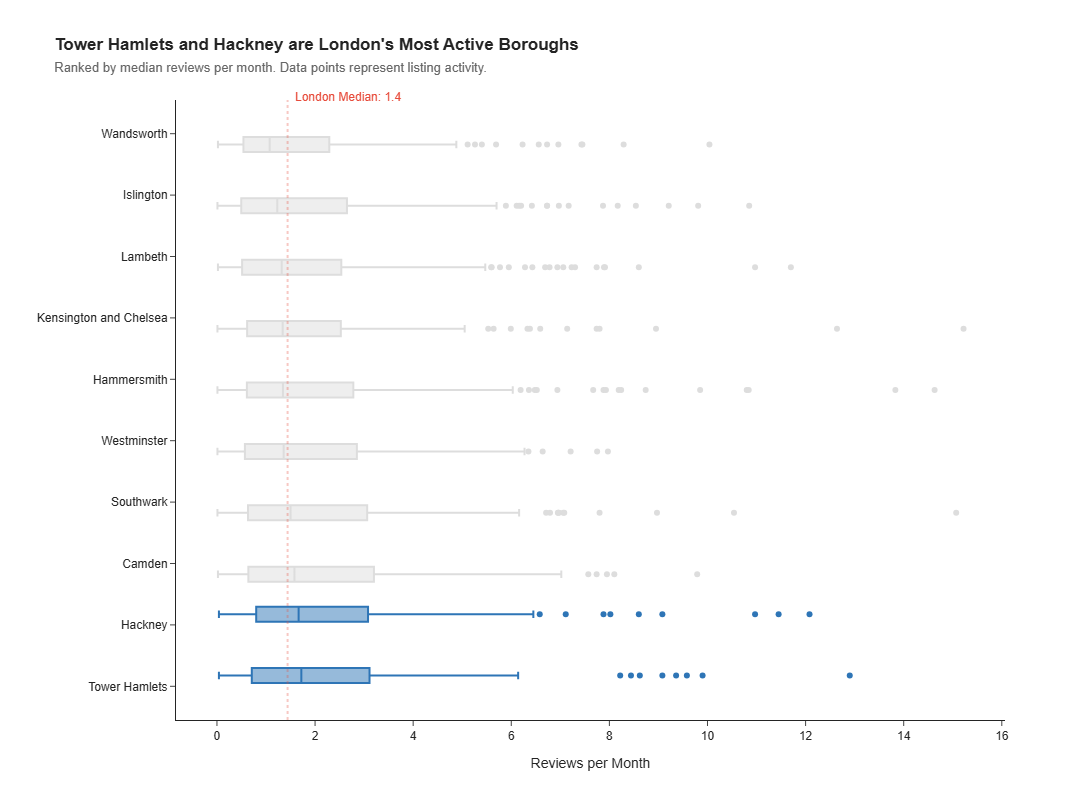

In [13]:
# Task 2
# 1. Filter out listings with zero reviews
df_active = df_cap[df_cap['reviews_per_month'] > 0].copy()

# 2. Calculate median activity per borough and sort
borough_stats = df_active.groupby('neighbourhood')['reviews_per_month'].median().sort_values(ascending=True)
sorted_boroughs = borough_stats.index.tolist()

# 3. Get the names of the top 2 most active boroughs
top_2_boroughs = sorted_boroughs[-2:] 

# 4. Highlight column
df_active['highlight'] = df_active['neighbourhood'].apply(
    lambda x: 'Top Active' if x in top_2_boroughs else 'Other'
)

# 5. Build the box plot
fig2 = px.box(
    df_active, 
    x="reviews_per_month", 
    y="neighbourhood",
    color="highlight",
    category_orders={"neighbourhood": sorted_boroughs},
    color_discrete_map={'Top Active': '#2E75B6', 'Other': '#DDDDDD'},
    points="outliers",
    orientation='h',
    template='simple_white',
    # Dynamic title using the borough names
    title=f"<b>{top_2_boroughs[1]} and {top_2_boroughs[0]} are London's Most Active Boroughs</b><br><span style='font-size:13px; color:#666666'>Ranked by median reviews per month. Data points represent listing activity.</span>",
    labels={'reviews_per_month': 'Reviews per Month', 'neighbourhood': ''},
    height=800
)

# 6. Add the global median reference line (Refined with Label)
global_median = df_active['reviews_per_month'].median()
fig2.add_vline(
    x=global_median, 
    line_dash="dot", 
    line_color="#E74C3C",
    line_width=2,
    layer='above'        
)

# Add annotation for the line
fig2.add_annotation(
    x=global_median, y=1.02, 
    yref='paper',
    text=f"London Median: {global_median:.1f}",
    showarrow=False, 
    font=dict(color="#E74C3C", size=12, family="Arial"),
    xanchor='left', 
    xshift=5
)

# 7. Final Polish
fig2.update_layout(
    showlegend=False,
    font=dict(family="Arial"),
    margin=dict(l=160, t=100) # Added top margin for annotation
)

fig2.show()
